In [1]:
import ee
import pwtt

Matplotlib is building the font cache; this may take a moment.


In [9]:
import pandas as pd, json, ee
ee.Initialize(project="war-damage-504215")

df = pd.read_csv("data/one_month/Makariv_20220316_1_footprints.csv")
# footprints are EPSG:4326 already
df["centroid"] = df[".geo"].apply(
    lambda g: ee.Geometry(json.loads(g)).centroid(1)
)
# for each centroid: build a fixed-size buffer/patch, sample the
# pre/post Sentinel-1 stack, export as GeoTIFF with label=class

In [ ]:
"""
Export Sentinel-1 image patches for each labelled building footprint,
ready for CNN training. Mirrors PWTT's own S1 preprocessing so the pixels
match the signal the `class` labels were generated from.

Output: TFRecord shards on Google Drive, one 4-channel patch + label per footprint.
"""
import json
import pandas as pd
import ee
from pwtt import lee_filter          # refined-Lee, exported by the pwtt package

ee.Initialize(project="war-damage-504215")

# ---------------------------------------------------------------------------
# 1. Parameters  (read straight off the filename: Makariv_20220316_1_footprints)
# ---------------------------------------------------------------------------
WAR_START       = "2022-02-22"   # Ukraine invasion (country-specific, see note below)
INFERENCE_START = "2022-03-16"   # the date embedded in the filename = annotation date
PRE_INTERVAL    = 12             # months of pre-war reference (PWTT default)
POST_INTERVAL   = 1              # months  -> the "_1_" / one_month folder
PATCH_RADIUS    = 16             # pixels; patch is (2r+1)=33 px ≈ 330 m at 10 m/px
SCALE           = 10             # Sentinel-1 native resolution (m)

war_start = ee.Date(WAR_START)
inf_start = ee.Date(INFERENCE_START)
PATCH     = 2 * PATCH_RADIUS + 1

# ---------------------------------------------------------------------------
# 2. Labelled points from the footprint centroids (needed first, to get the AOI)
# ---------------------------------------------------------------------------
df = pd.read_csv("data/one_month/Makariv_20220316_1_footprints.csv")

def row_to_feature(idx, row):
    pt = ee.Geometry(json.loads(row[".geo"])).centroid(1)   # already EPSG:4326
    return ee.Feature(pt, {"class": int(row["class"]), "idx": int(idx)})

# For a few thousand footprints this client-side build is fine.
# For big cities (Gaza ~228k) upload the footprints as a GEE asset and map server-side.
fc  = ee.FeatureCollection([row_to_feature(i, r) for i, r in df.iterrows()])
aoi = fc.geometry().bounds()

# ---------------------------------------------------------------------------
# 3. Sentinel-1 stack, built exactly like PWTT's _setup_s1()
# ---------------------------------------------------------------------------
s1 = (ee.ImageCollection("COPERNICUS/S1_GRD_FLOAT")
      .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
      .filter(ee.Filter.eq("instrumentMode", "IW"))
      .filterBounds(aoi)                     # keeps us in one UTM zone, and speeds things up
      .select(["VV", "VH"])
      .map(lee_filter)                       # speckle filter, per image
      .map(lambda img: img.log()))           # PWTT works in log(linear power)

# Grab S1's native projection (UTM @ 10 m) from an image over this city.
s1_proj = s1.first().projection()

pre  = s1.filterDate(war_start.advance(-PRE_INTERVAL, "month"), war_start)
post = s1.filterDate(inf_start, inf_start.advance(POST_INTERVAL, "month"))

# 4-channel input: pre-war mean + post-war mean for VV and VH.
#
# CRITICAL: .mean() is a reduction, so the composite loses its projection and
# defaults to WGS84 at 1 degree/pixel. Without setDefaultProjection every patch
# collapses to ~1x1 (sampleRectangle) or spans the globe (neighborhoodToArray).
# Pinning it back to S1's 10 m grid is what makes the patches real.
#
# unmask(0) then guarantees a full, fixed-size array even where a period has no
# coverage — otherwise masked pixels make the arrays ragged and the export fails.
stack = (pre.mean().rename(["pre_VV", "pre_VH"])
         .addBands(post.mean().rename(["post_VV", "post_VH"]))
         .unmask(0)
         .toFloat()
         .setDefaultProjection(s1_proj))

# ---------------------------------------------------------------------------
# 4. Cut a fixed patch around every point
# ---------------------------------------------------------------------------
kernel  = ee.Kernel.rectangle(PATCH_RADIUS, PATCH_RADIUS, "pixels")
patched = stack.neighborhoodToArray(kernel)   # each band -> a PATCH x PATCH array

samples = patched.sampleRegions(
    collection=fc,
    scale=SCALE,
    geometries=False,
    tileScale=4,          # bump if you hit "computed value too large"
)

# ---------------------------------------------------------------------------
# 5. Export to Drive as TFRecords
# ---------------------------------------------------------------------------
task = ee.batch.Export.table.toDrive(
    collection=samples,
    description="makariv_patches",
    folder="pwtt_cnn",
    fileNamePrefix="Makariv_20220316_1",
    fileFormat="TFRecord",
    selectors=["pre_VV", "pre_VH", "post_VV", "post_VH", "class", "idx"],
)
task.start()
print("Export started — monitor with task.status() or the GEE Tasks tab.")

# ---------------------------------------------------------------------------
# Quick local sanity check BEFORE committing to the full export (optional)
# With setDefaultProjection in place this now returns (33, 33), not (1, 1).
# ---------------------------------------------------------------------------
# import numpy as np
# r  = df.iloc[0]
# pt = ee.Geometry(json.loads(r[".geo"])).centroid(1)
# region = pt.buffer(PATCH_RADIUS * SCALE).bounds()
# arr = stack.sampleRectangle(region=region, defaultValue=0).getInfo()["properties"]
# print(np.array(arr["pre_VV"]).shape)   # -> (33, 33)

# ---------------------------------------------------------------------------
# Reading the TFRecords back after the export finishes
# ---------------------------------------------------------------------------
# import tensorflow as tf
# spec = {b: tf.io.FixedLenFeature([PATCH, PATCH], tf.float32)
#         for b in ["pre_VV", "pre_VH", "post_VV", "post_VH"]}
# spec["class"] = tf.io.FixedLenFeature([], tf.int64)
#
# def parse(ex):
#     d = tf.io.parse_single_example(ex, spec)
#     img = tf.stack([d["pre_VV"], d["pre_VH"], d["post_VV"], d["post_VH"]], -1)
#     return img, d["class"]
#
# files = tf.io.gfile.glob("pwtt_cnn/Makariv_20220316_1*.tfrecord.gz")
# ds = tf.data.TFRecordDataset(files, compression_type="GZIP").map(parse)

Export started — monitor with task.status() or the GEE Tasks tab.


In [14]:
import numpy as np
r  = df.iloc[0]
pt = ee.Geometry(json.loads(r[".geo"])).centroid(1)
region = pt.buffer(PATCH_RADIUS * SCALE).bounds()
arr = stack.sampleRectangle(region=region, defaultValue=0).getInfo()["properties"]
print(np.array(arr["pre_VV"]).shape)   # -> (33, 33)

(34, 34)


In [21]:
task.status()

{'state': 'COMPLETED',
 'description': 'makariv_patches',
 'priority': 100,
 'creation_timestamp_ms': 1785598543328,
 'update_timestamp_ms': 1785598621842,
 'start_timestamp_ms': 1785598549811,
 'task_type': 'EXPORT_FEATURES',
 'destination_uris': ['https://drive.google.com/#folders/1PUXt2eXYHCURsz0q62_SyCUoq8g_1an7'],
 'attempt': 1,
 'batch_eecu_usage_seconds': 290.6617736816406,
 'id': '45CY6FK4VFNMBRD2HN2E7JZO',
 'name': 'projects/war-damage-504215/operations/45CY6FK4VFNMBRD2HN2E7JZO'}

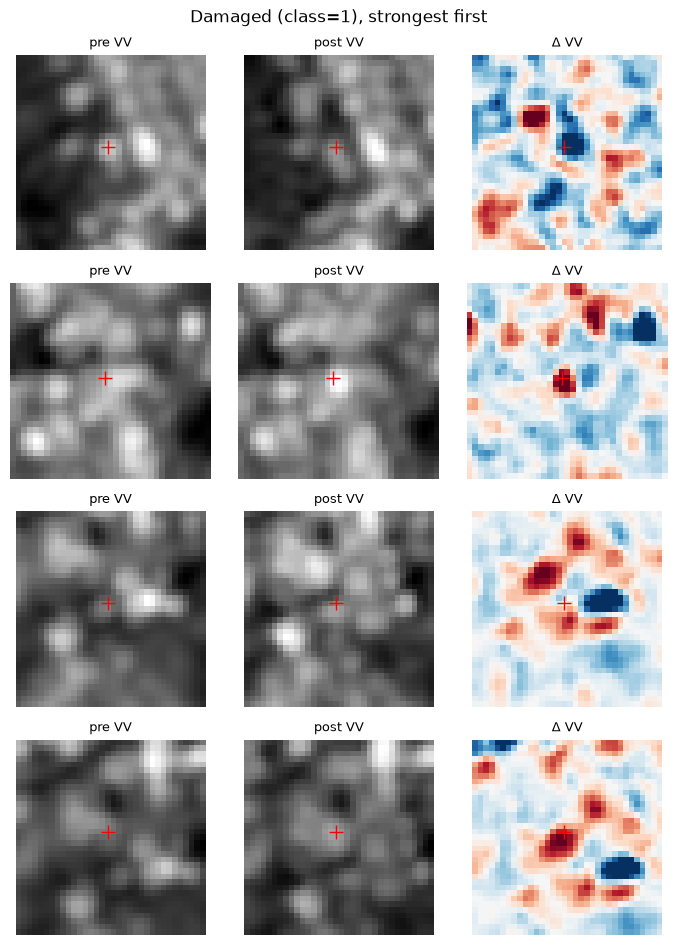

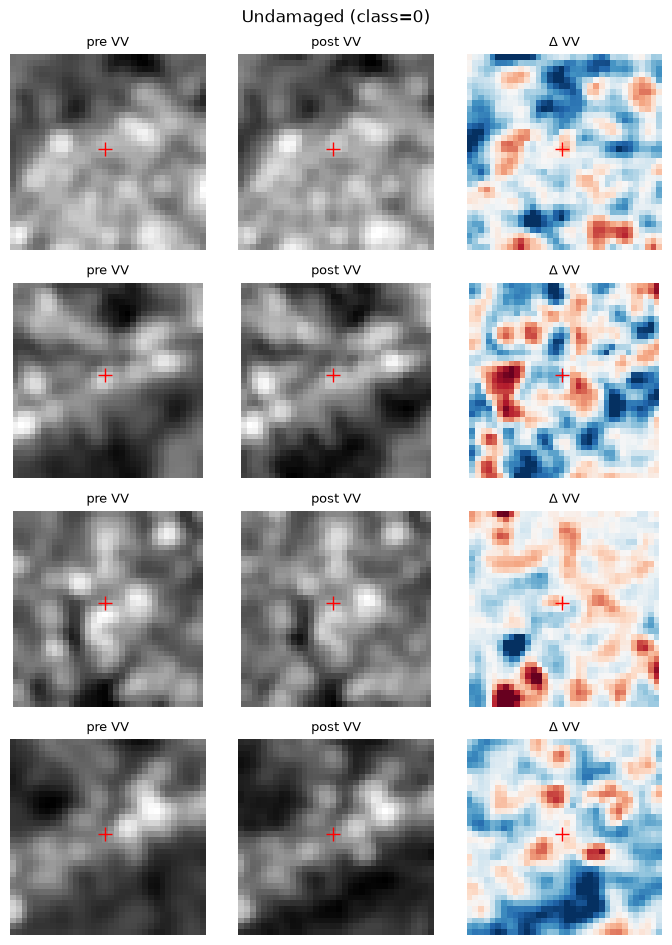

In [20]:
import numpy as np, json
import matplotlib.pyplot as plt

def get_patch(row):
    pt = ee.Geometry(json.loads(row[".geo"])).centroid(1)
    region = pt.buffer(PATCH_RADIUS * SCALE).bounds()
    p = stack.sampleRectangle(region=region, defaultValue=0).getInfo()["properties"]
    return {b: np.array(p[b]) for b in ["pre_VV", "pre_VH", "post_VV", "post_VH"]}

def show(rows, title):
    fig, axes = plt.subplots(len(rows), 3, figsize=(7, 2.4 * len(rows)))
    for axr, (_, r) in zip(np.atleast_2d(axes), rows.iterrows()):
        p    = get_patch(r)
        diff = p["post_VV"] - p["pre_VV"]           # damage lives here
        d    = np.nanpercentile(np.abs(diff), 98) or 1
        axr[0].imshow(p["pre_VV"],  cmap="gray");                 axr[0].set_title("pre VV",  fontsize=9)
        axr[1].imshow(p["post_VV"], cmap="gray");                 axr[1].set_title("post VV", fontsize=9)
        axr[2].imshow(diff, cmap="RdBu_r", vmin=-d, vmax=d);      axr[2].set_title("Δ VV",    fontsize=9)
        for ax in axr:
            ax.plot(PATCH_RADIUS, PATCH_RADIUS, "r+", ms=10)      # centre = the building
            ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

dmg   = df[df["class"] == 1].sort_values("max_change", ascending=False).head(4)
undmg = df[df["class"] == 0].head(4)
show(dmg,   "Damaged (class=1), strongest first")
show(undmg, "Undamaged (class=0)")

In [24]:
import tensorflow as tf
spec = {b: tf.io.FixedLenFeature([PATCH, PATCH], tf.float32)
        for b in ["pre_VV", "pre_VH", "post_VV", "post_VH"]}
spec["class"] = tf.io.FixedLenFeature([], tf.int64)

def parse(ex):
    d = tf.io.parse_single_example(ex, spec)
    img = tf.stack([d["pre_VV"], d["pre_VH"], d["post_VV"], d["post_VH"]], -1)
    return img, d["class"]

files = tf.io.gfile.glob("pwtt_cnn/Makariv_20220316_1*.tfrecord.gz")
ds = tf.data.TFRecordDataset(files, compression_type="GZIP").map(parse)

In [23]:
!uv pip install tensorflow

Using Python 3.13.9 environment at: /Users/breitner/local_research/war_damage/.venv
Resolved 32 packages in 2.50s                                        
⠙ Preparing packages... (0/20)                                                  
⠙ Preparing packages... (0/20)------------------     0 B/213.40 MiB          
⠙ Preparing packages... (0/20)------------------ 16.00 KiB/213.40 MiB        
⠙ Preparing packages... (0/20)------------------ 32.00 KiB/213.40 MiB        
⠙ Preparing packages... (0/20)------------------ 48.00 KiB/213.40 MiB        
⠙ Preparing packages... (0/20)------------------ 61.07 KiB/213.40 MiB        
⠙ Preparing packages... (0/20)------------------ 77.07 KiB/213.40 MiB        
⠙ Preparing packages... (0/20)------------------ 93.07 KiB/213.40 MiB        
⠙ Preparing packages... (0/20)------------------ 109.07 KiB/213.40 MiB       
⠙ Preparing packages... (0/20)------------------ 125.07 KiB/213.40 MiB       
⠙ Preparing packages... (0/20)------------------ 141.07 KiB/213

In [ ]:
"""
Siamese CNN for building-damage detection from Sentinel-1 patches.

A single shared encoder embeds the pre-war and post-war patch into the same
feature space; the classifier sees [f_pre, f_post, |f_pre - f_post|], so the
signal it learns is the *change*, not the raw scene.

Input : two 2-channel (VV, VH) 33x33 patches per building, from export_s1_patches.py
Target : class (1 = damaged, 0 = undamaged)
"""
import glob
import tensorflow as tf

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
PATCH  = 33
BATCH  = 128
EPOCHS = 60

# Split by CITY, not by random row — buildings within a city are spatially
# autocorrelated, so a random split leaks neighbours across train/val and
# massively inflates scores. Hold out whole cities (this is how PWTT is judged).
TRAIN_FILES = glob.glob("pwtt_cnn/train/*/*.tfrecord.gz")   # e.g. Chernihiv, Irpin, Hostomel, ...
VAL_FILES   = glob.glob("pwtt_cnn/val/*/*.tfrecord.gz")     # e.g. Makariv, Bucha
assert TRAIN_FILES and VAL_FILES, "No TFRecords found — check the paths / that exports finished."

# ---------------------------------------------------------------------------
# 1. Parse TFRecords -> ((pre, post), label)
# ---------------------------------------------------------------------------
BANDS = ["pre_VV", "pre_VH", "post_VV", "post_VH"]
_spec = {b: tf.io.FixedLenFeature([PATCH, PATCH], tf.float32) for b in BANDS}
_spec["class"] = tf.io.FixedLenFeature([], tf.int64)

def _clean(t):                                   # kill any log(0) -> -inf leftovers
    return tf.where(tf.math.is_finite(t), t, tf.zeros_like(t))

def parse(ex):
    d = tf.io.parse_single_example(ex, _spec)
    pre  = _clean(tf.stack([d["pre_VV"],  d["pre_VH"]],  axis=-1))   # (33,33,2)
    post = _clean(tf.stack([d["post_VV"], d["post_VH"]], axis=-1))
    y = tf.cast(d["class"], tf.float32)
    return (pre, post), y

def make_ds(files, training):
    ds = tf.data.TFRecordDataset(files, compression_type="GZIP",
                                 num_parallel_reads=tf.data.AUTOTUNE)
    ds = ds.map(parse, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(8192)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(TRAIN_FILES, training=True)
val_ds   = make_ds(VAL_FILES,   training=False)

# ---------------------------------------------------------------------------
# 2. Per-channel standardization, adapted on TRAIN patches only
#    (pre and post pooled, since they share the encoder)
# ---------------------------------------------------------------------------
norm = tf.keras.layers.Normalization(axis=-1)
adapt_ds = (make_ds(TRAIN_FILES, training=False)
            .map(lambda xy, y: tf.concat([xy[0], xy[1]], axis=0))   # pool pre+post
            .take(300))
norm.adapt(adapt_ds)

# ---------------------------------------------------------------------------
# 3. Shared encoder + Siamese head
# ---------------------------------------------------------------------------
def build_encoder():
    inp = tf.keras.Input((PATCH, PATCH, 2))
    x = norm(inp)
    for f in (32, 32):
        x = tf.keras.layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D()(x)
    for f in (64, 64):
        x = tf.keras.layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    return tf.keras.Model(inp, x, name="encoder")

def build_siamese():
    encoder = build_encoder()                    # built ONCE -> weights shared
    pre_in  = tf.keras.Input((PATCH, PATCH, 2), name="pre")
    post_in = tf.keras.Input((PATCH, PATCH, 2), name="post")
    f_pre, f_post = encoder(pre_in), encoder(post_in)
    diff = tf.keras.layers.Lambda(lambda t: tf.abs(t[0] - t[1]),
                                  name="abs_diff")([f_pre, f_post])
    x = tf.keras.layers.Concatenate()([f_pre, f_post, diff])
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model([pre_in, post_in], out, name="siamese_damage")

model = build_siamese()
model.summary()

# ---------------------------------------------------------------------------
# 4. Compile — focal loss handles the class imbalance; track PR-AUC as primary
# ---------------------------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryFocalCrossentropy(apply_class_balancing=True, gamma=2.0),
    metrics=[tf.keras.metrics.AUC(name="roc_auc"),
             tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max",
                                     patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("siamese_damage.keras",
                                       monitor="val_pr_auc", mode="max",
                                       save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max",
                                         factor=0.5, patience=5),
]

# ---------------------------------------------------------------------------
# 5. Train
# ---------------------------------------------------------------------------
model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

# ---------------------------------------------------------------------------
# 6. Pick an operating threshold on the held-out cities
#    (mirrors PWTT's precision/recall threshold table)
# ---------------------------------------------------------------------------
import numpy as np
y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
y_prob = model.predict(val_ds).ravel()

print(f"\nval ROC-AUC {tf.keras.metrics.AUC()(y_true, y_prob):.3f}  "
      f"PR-AUC {tf.keras.metrics.AUC(curve='PR')(y_true, y_prob):.3f}")
print(f"{'thr':>5} {'prec':>6} {'recall':>7} {'f1':>6}")
for thr in (0.1, 0.2, 0.3, 0.5, 0.7, 0.9):
    pred = y_prob >= thr
    tp = np.sum(pred & (y_true == 1)); fp = np.sum(pred & (y_true == 0))
    fn = np.sum(~pred & (y_true == 1))
    prec = tp / (tp + fp + 1e-9); rec = tp / (tp + fn + 1e-9)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    print(f"{thr:5.2f} {prec:6.3f} {rec:7.3f} {f1:6.3f}")

In [32]:
ee.batch.Task.list()

[<Task NSMWKONNBPLK6XMQPSV66ASQ EXPORT_FEATURES: Trostianets_003 (COMPLETED)>,
 <Task X34FWBV2EVMLW5ENAUQ2SC2V EXPORT_FEATURES: Trostianets_002 (COMPLETED)>,
 <Task P4UQOX25HKLSZ2CQSC5I6FES EXPORT_FEATURES: Trostianets_001 (COMPLETED)>,
 <Task UIETF7FUWJK5T74G3MHIYW57 EXPORT_FEATURES: Trostianets_000 (COMPLETED)>,
 <Task ZWLME75R4PNHM4B4VGRFXDSF EXPORT_FEATURES: Sumy_011 (COMPLETED)>,
 <Task FXWZWHIDBKUKAOSYECAN7KQC EXPORT_FEATURES: Sumy_010 (COMPLETED)>,
 <Task ACT5NLVJGYEGXC7XS4EGDRDQ EXPORT_FEATURES: Sumy_009 (COMPLETED)>,
 <Task VYE3LFKHTQHX6JMNBGSOGMNT EXPORT_FEATURES: Sumy_008 (COMPLETED)>,
 <Task BRDLX2V5CIWZMK5IZOWCAQFO EXPORT_FEATURES: Sumy_007 (COMPLETED)>,
 <Task 53G2YSJMLMZENQOD6JDTZ5MI EXPORT_FEATURES: Sumy_006 (COMPLETED)>,
 <Task XEVHESPBHQ5MQT56HF2ASAYG EXPORT_FEATURES: Sumy_005 (COMPLETED)>,
 <Task XMYM5QMLWNPXP53RQCFIMT4U EXPORT_FEATURES: Sumy_004 (COMPLETED)>,
 <Task 73XKE6CTTRE76XXXVWPANGZN EXPORT_FEATURES: Sumy_003 (COMPLETED)>,
 <Task IWVDMKGHIMUD5APMHPJ3XW6C EXPO